In [1]:
# auto reload modules
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
from cns.process.aggregation import group_samples
from cns.utils.selection import get_cns_for_type, only_aut
from cns.display.plot import fig_lines
from cns.data_utils import main_load_data, select_CNS_samples, load_merged_samples, save_cns_fig

In [3]:
load_merged_samples(print_info=True);

Total samples: 14174
PCAWG
Total samples: 2583
190 samples are CN neutral (below 0.00140)
3 samples have low coverage (below 0.97816)
Filtered samples: 2390
TRACERx
Total samples: 1620
0 samples are CN neutral (below 0.00010)
19 samples have low coverage (below 0.93514)
286 samples do not have exact type
Filtered samples: 1322
TCGA_hg19
Total samples: 9971
658 samples are CN neutral (below 0.00030)
16 samples have low coverage (below 0.99826)
Filtered samples: 9297
Total samples: 13009


In [4]:
bin_size = "3MB"
samples_df, cns_df = main_load_data(bin_size)

In [5]:
_, arms_df = main_load_data("arms")
arms_df

,sample_id,chrom,start,end,major_cn,minor_cn,name
0,SP101724,chr1,0,121485434,2.093344,1.955438,chr1p_0
1,SP101724,chr1,142535434,249250621,2.033594,1.727148,chr1p_1
2,SP101724,chr10,0,39154935,2.160304,1.061700,chr10p_0
3,SP101724,chr10,42354935,135534747,2.028445,1.052366,chr10p_1
4,SP101724,chr11,0,51594205,2.037535,2.000000,chr11p_0
...,...,...,...,...,...,...,...
559533,TCGA-ZX-AA5X,chr8,46838887,146364022,2.000000,1.985682,chr8p_1
559534,TCGA-ZX-AA5X,chr9,0,47317679,2.000000,2.000000,chr9p_0
559535,TCGA-ZX-AA5X,chr9,65467679,141213431,2.000000,2.000000,chr9p_1
559536,TCGA-ZX-AA5X,chrX,0,58582012,2.000000,2.000000,chrXp_0


In [6]:
data = only_aut(arms_df)
pos = data[['chrom', 'start', 'end']].drop_duplicates()
groups = data.groupby("sample_id")
# index each entry within a group
data["index"] = groups.cumcount()
major_cn = data.pivot(index="sample_id", columns="index", values="major_cn")
minor_cn = data.pivot(index="sample_id", columns="index", values="minor_cn")
indices = major_cn.index    


C:\Users\adams\AppData\Local\Temp\ipykernel_14820\1305909553.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["index"] = groups.cumcount()


In [7]:
samples_df["type"].value_counts().head(6).sum()

5172

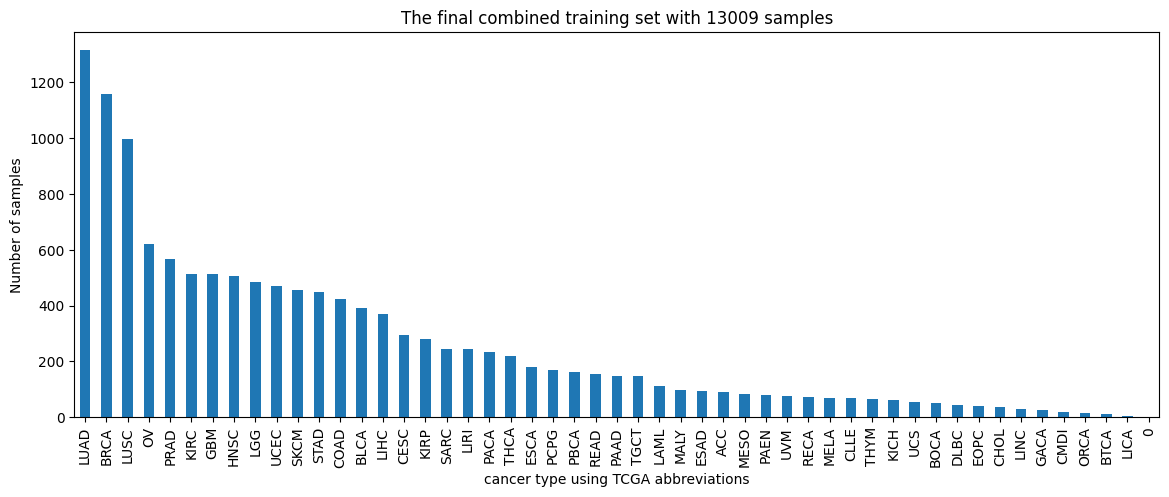

In [8]:
plt.rcParams["figure.figsize"] = (14,5)
samples_df["type"].value_counts().plot(kind="bar")
plt.title("The final combined training set with {} samples".format(len(samples_df)))
plt.ylabel("Number of samples")
plt.xlabel("cancer type using TCGA abbreviations")
save_cns_fig("cancer_types")

In [9]:
from cns.process.aggregation import add_total_cn

top_6 = samples_df["type"].value_counts().head(6).index
top_6_cns_df = [add_total_cn(group_samples(get_cns_for_type(cns_df, samples_df, cancer_type))) for cancer_type in top_6]

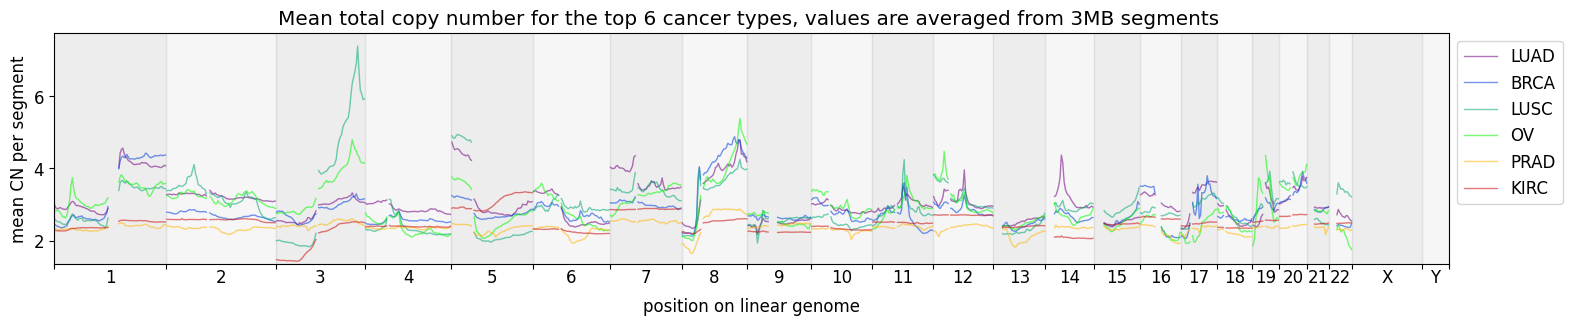

In [10]:
# double font size
plt.rcParams["font.size"] = 12
fig_lines([only_aut(x) for x in top_6_cns_df], top_6, column="total_cn")
# add title
plt.title(f"Mean total copy number for the top 6 cancer types, values are averaged from {bin_size} segments ")
save_cns_fig("top_6_profiles")

C:\Users\adams\AppData\Local\Temp\ipykernel_14820\3577424710.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sub_samples = all_samples.groupby('type').apply(lambda x: x.sample(n=50, replace=True)).drop('type', axis=1).reset_index().set_index("sample_id")


(<Figure size 1800x300 with 1 Axes>,
 <Axes: xlabel='position on linear genome', ylabel='mean CN per segment'>)

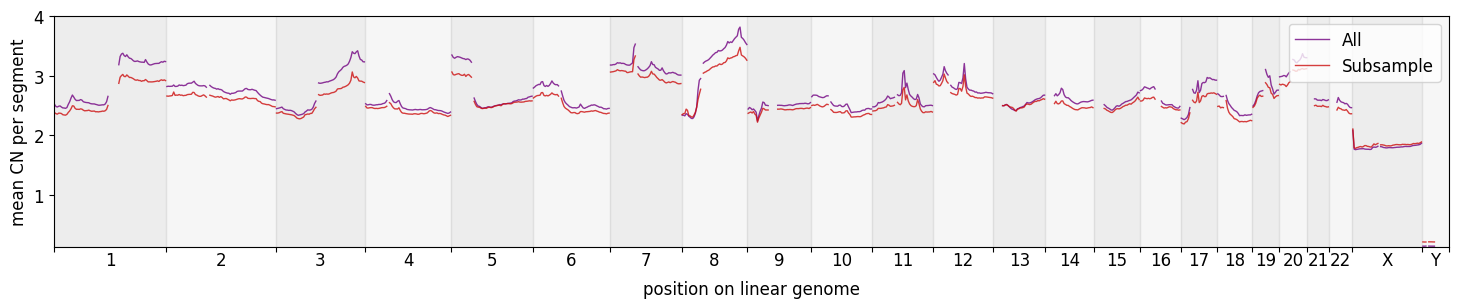

In [11]:
above_50 = samples_df["type"].value_counts().where(lambda x: x >= 50).where(lambda x: x != "Other").dropna().index.values
all_samples = samples_df.query("type in @above_50")
sub_samples = all_samples.groupby('type').apply(lambda x: x.sample(n=50, replace=True)).drop('type', axis=1).reset_index().set_index("sample_id")
# select only 50 samples for each type to obtain balanced mean
selection = [add_total_cn(group_samples(select_CNS_samples(cns_df, samples))) for samples in [all_samples, sub_samples]]
fig_lines(selection, ["All", "Subsample"], column="total_cn")